<a href="https://colab.research.google.com/github/ShivaniAnand424/Complete-Python-3-Bootcamp/blob/master/ShivaniAnand_B4_b1_SPL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/drive/MyDrive/AI_Job_Market_Trends_2026.csv')
df

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9


# **Dataset Loading and Exploration**

In [6]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [8]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


# **Data Preprocessing**

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop ID column
df.drop("job_id", axis=1, inplace=True)

# Fill missing values (numeric + categorical)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
numeric_cols = df.select_dtypes(include=["number"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

for col in categorical_cols:
    if df[col].dtype.name == "category":
        df[col] = df[col].cat.add_categories("Unknown")
    df[col] = df[col].fillna("Unknown")


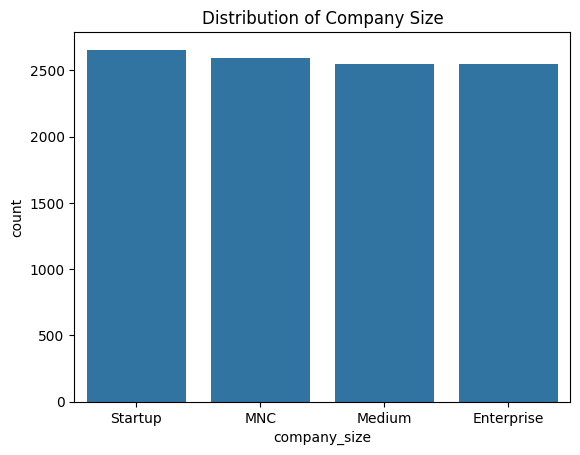

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='company_size', data=df) # Changed 'NObeyesdad' to 'company_size'
plt.title('Distribution of Company Size') # Updated title for clarity
plt.show()

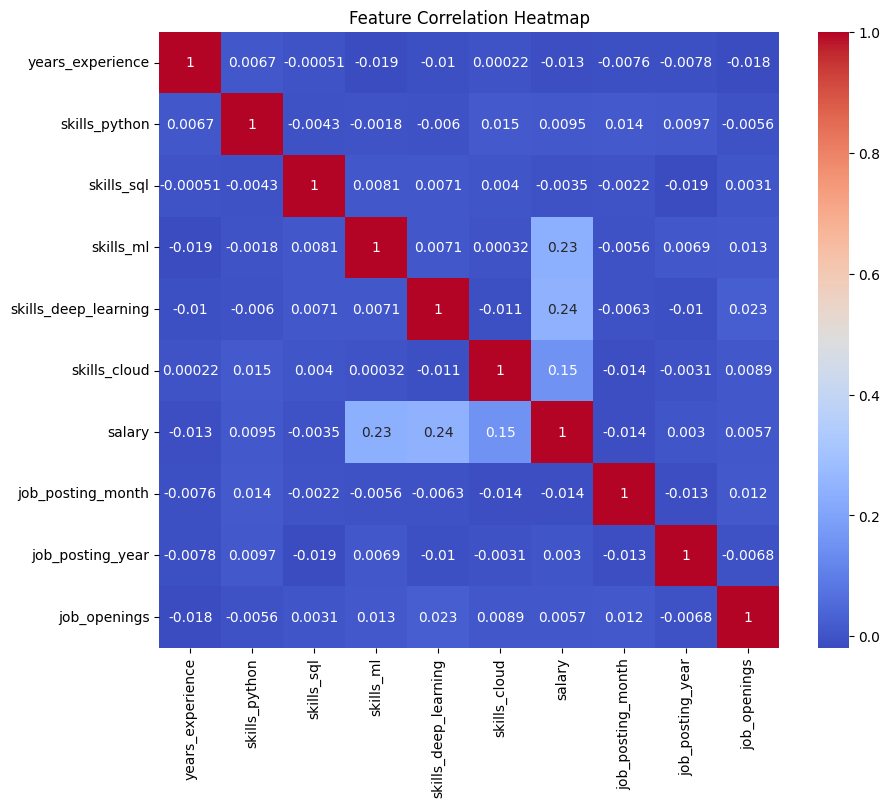

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

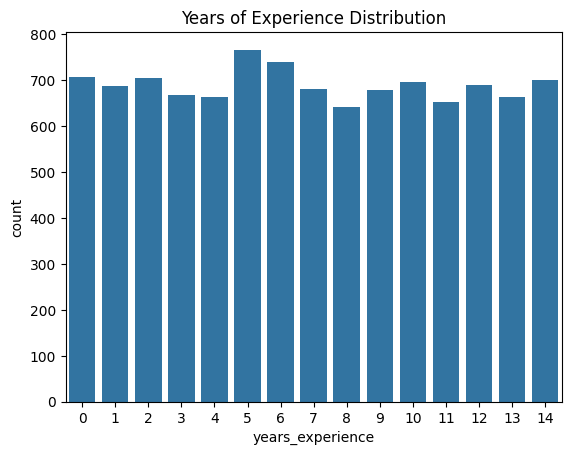

In [12]:
sns.countplot(x='years_experience', data=df)
plt.title('Years of Experience Distribution')
plt.show()

In [13]:
df["salary_class"] = pd.qcut(
    df["salary"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Drop original salary
df.drop("salary", axis=1, inplace=True)

# **Train and test**

In [14]:
X = df.drop("salary_class", axis=1)
y = df["salary_class"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

Logistic Regression Accuracy: 0.94
Decision Tree Accuracy: 0.71
Random Forest Accuracy: 0.75


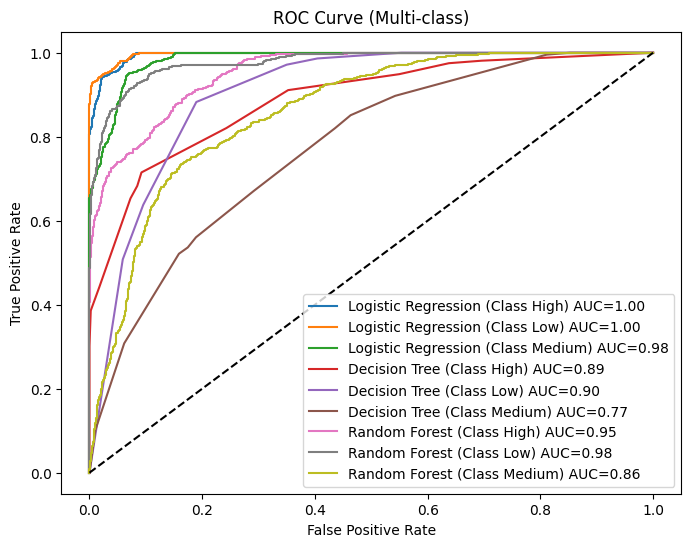

In [19]:
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Convert target into binary format for ROC (multi-class)
classes = y.unique()
y_bin = label_binarize(y, classes=classes)

# Use SAME train-test split (outside loop)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)

# Scale data (important)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(8, 6))

for name, model in models.items():

    # Set parameters
    if "Random" in name:
        model.set_params(n_estimators=50, max_depth=5, random_state=7)
    elif "Decision" in name:
        model.set_params(max_depth=4, random_state=7)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # ✅ Accuracy (correct way)
    acc = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", round(acc, 2))

    # ✅ ROC Curve (only if probability exists)
    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(X_test)

        # Compute ROC for each class
        for i in range(len(classes)):
            fpr, tpr, _ = roc_curve(
                (y_test == classes[i]).astype(int),
                y_score[:, i]
            )
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr,
                     label=f"{name} (Class {classes[i]}) AUC={roc_auc:.2f}")

# Random line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.model_selection import train_test_split

results = []

_, _, _, y_test_consistent = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    # Use y_test_consistent instead of the overwritten y_test
    acc = accuracy_score(y_test_consistent, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test_consistent, y_pred))

    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)


Logistic Regression
Accuracy: 0.9405509908168197
              precision    recall  f1-score   support

        High       0.96      0.94      0.95       670
         Low       0.98      0.93      0.96       718
      Medium       0.88      0.95      0.91       681

    accuracy                           0.94      2069
   macro avg       0.94      0.94      0.94      2069
weighted avg       0.94      0.94      0.94      2069


Decision Tree
Accuracy: 0.7095215079748671
              precision    recall  f1-score   support

        High       0.82      0.72      0.77       670
         Low       0.69      0.88      0.78       718
      Medium       0.62      0.52      0.57       681

    accuracy                           0.71      2069
   macro avg       0.71      0.71      0.70      2069
weighted avg       0.71      0.71      0.70      2069


Random Forest
Accuracy: 0.7573707104881585
              precision    recall  f1-score   support

        High       0.82      0.81      0.82  

In [22]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

best_model = trained_models[best_model_name]

Best Model: Logistic Regression


In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


_, _, _, y_test_consistent = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = best_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test_consistent, y_pred))

Confusion Matrix:
 [[632   0  38]
 [  0 670  48]
 [ 24  13 644]]


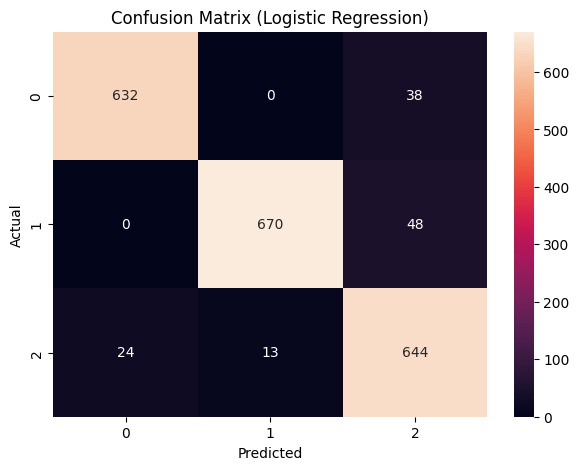

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

_, _, _, y_test_consistent = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test_consistent, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({best_model_name})') # Use the actual best model's name
plt.show()

In [25]:
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Using relevant existing numeric columns for GUI input
gui_columns = ['years_experience', 'skills_python', 'job_openings', 'job_posting_year']

# Use the 'salary_class' as the target variable, which was previously created
y_gui = df['salary_class']

X_gui = df[gui_columns]
X_train_gui, X_test_gui, y_train_gui, y_test_gui = train_test_split(X_gui, y_gui, test_size=0.2, random_state=7)

scaler_gui = StandardScaler()
X_train_scaled_gui = scaler_gui.fit_transform(X_train_gui)

hybrid_model_gui = VotingClassifier(
    estimators=[('lr', LogisticRegression()), ('svm', SVC(probability=True)), ('xgb', XGBClassifier())],
    voting='soft'
)
hybrid_model_gui.fit(X_train_scaled_gui, y_train_gui)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('svm', SVC(probability=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [26]:
import pickle
from google.colab import files

# Save best model
with open("salary_classifier_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("salary_classifier_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature column names
with open("salary_classifier_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Pickle files saved successfully!")

Pickle files saved successfully!


In [27]:
files.download("salary_classifier_model.pkl")
files.download("salary_classifier_scaler.pkl")
files.download("salary_classifier_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>